# Pixel-Level Semantic Segmentation with U-Net and ResNet-34 Backbone

## Overview
This notebook implements an end-to-end semantic segmentation pipeline using FastAI and PyTorch. It leverages the CamVid Tiny dataset to train a U-Net architecture for dense, pixel-level object classification, complete with custom accuracy metrics and model evaluation.

## Key Technical Components
* **Dataset & Loader Configuration:** Utilizes `SegmentationDataLoaders.from_label_func` to pair raw RGB scene images with ground-truth segmentation mask files using a custom filename-matching lambda mapping.
* **Architecture & Transfer Learning:** Instantiates a **U-Net** semantic segmentation model driven by a pretrained **ResNet-34** encoder backbone via `unet_learner`, fine-tuned over 8 epochs.
* **Custom Metric Engineering:** Implements a custom pixel accuracy metric (`acc_seg`) that matches predicted class argmax tensors against squeezed target ground-truth maps.
* **Evaluation & Inference:** Evaluates validation loss alongside global pixel accuracy and foreground-specific accuracy metrics, mapping model predictions back to human-readable class labels loaded from `codes.txt`.

-----------
-----------
-----------

# Computer Vision Application 2

# Computer Vision (as a Whole)

Computer Vision is a subfield of AI that enables machines to interpret, analyze, and understand visual data from the world around them, such as images and videos, much like humans do.

*  The core hierarchy(The "Big Three")

   * **Level 1: Image Classification("The Glimpse")**  *Simplest form in which we show AI an Image and it gives us a single label.*
      * The Question: "What is the object in the image?"
      * The Output: A label(e.g. a Cat) and a confidence score(e.g. 98%)
      * Usage: Detect "Bird vs Forest" model
      * Limitation: If there is a cat and a dog in one picture, a standard classifier gets confused or just picks the biggest one
   * **Level 2: Object Detection("The Pointing Finger")**  *This takes a step further. We not only want "what is there" but "where it is" as well.*
      * The Question: "Where are the objects and what are they?"
      * The Output: Bounding boxes(rectangles) drawn around objects, each with a label.
      * Usage: A Security camera drawing a box around a person walking into a restricted area.
      * Limitation: Objects aren't always square, overlapping problem, the diagonal problem(too much noise)
         
   * **Level 3: Image Segmentation("The Tracer")**  *This is the most Granular level(like with CamVid).*
       * The Question: "Which pixels belong to which object?"
       * The Output: A Mask(a pixel-perfect overlay)
       * Usage: Self-Driving cars(knowing where curve exactly is, car or bike or human), Medical AI(measuring the exact size of tumor)
       * Limitation: Heavy Computation Load{Final Boss(as of now): Panoptic Segmentation}

  * There are two sub-types of Segmentation:
    * Semantic Segmantation: "All cars are Blue."(It doesn't care if there are 5 cars; they are all just "Car-pixels" e.g CamVid model)
    * Instance Segmentation: "Car A is Blue, Car B is Red." (It separated individual objects).

Other advances and specialized Vision Tasks are Pose Estimation("The Skeleton"), Facial Landmark Detection, Depth Estimation("The 3D Eye"), Image Generation(Generative AI) etc.

# Image Segmentation

In [1]:
# 1. Force install the "Goldilocks" version of NumPy (not too old, not too new) used here as
#    numpy recently got updated and its causing a lot of compatilbilty issues with fastai
!pip install -Uqq "numpy>=2.0.0,<2.1.0" "fastai>=2.7.15"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.1/235.1 kB 7.0 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import *

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
# 1. Here we dont have to download the images from the internet rather we have the dataset, so importing DDGS and all makes no sense.
# 2. Instead we're directly fetching data from the one .tar file(like .zip) untar it and use it in our model.
# 3. fastcore also not imported here as all the things that we need in our project we got it 
#    "from fastai.vision.all import *" and fastai is built on top of fastcore so need need to import separately unnecessary things.
# 4. As we've already installed "Goldilocks" version of NumPy and fastai already so iskaggle is redundant here.

In [4]:
# This code block is the actual "engine room" of the deep learning pipeline
path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs = 8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt',dtype=str)
)
learn = unet_learner(dls, resnet34)
learn.fine_tune(8)

# 1. untar_data is a fastai utility that downloads and untars a compressed file(.tar{in datasets its usually .tar.gz}) and 
#    returns the local folder where it is saved.
#  * URLs.CAMVID_TINY points to a (mini version) of Cambridge Video database where it contains screenshots from a car's dashboard camera.
#    URLs is a helper class within fastai library. It is kind of container that stores the "web addresses" for many datasets for it to easy access and not remember long,messy URLs.
# 2. SegmentationDataLoader creates the Dataloaders, which are responsible for feeding batches of images into the GPU.
#  * from_label_func grabs its functionality from the label_func within for the purpose of finding the label(matching the label basically)
#  * path tells the loader where the data is present(here it is on AWS server, basically the location of CamVid Folder)
#  * bs=8 is the batch size 
#  * fnames = get_image_files(path/"images") is a list of all input image files. get_image_files is the helper function which looks in 
#    the /images subfolder and grabs the images(e.g. .../image/0001.jpg, .../image/0002.jpg etc.)
# 5. np.loadtext is a NumPy function that reads a text file and turns into a NumPy array(list of words here in the text file)
#  * Computer actually sees numbers and predicts pixel is Class1, Class5 etc., the codes list acts as translator for us to identify accurate labels.


#  * U-Net is a type of NN architecture designed specifically for segmentation tasks. It looks at image, shrinks it down 
#    to understand"What is in this picture?", then blows it back to original size to decide "Which pixel belongs to what?". 
#    It is called U-Net as the diagram of dataflow looks like U.

'''
 # codes = np.loadtxt(path/'codes.txt', dtype=str)
    It is a list of class names.
    In segmentation mask, the computer doesn't see labels like "Sky" or "Car" instead it sees numbers (e.g. Pixel1=Class0, Pixel2=Class14)
    * codes.txt contains the human-readable names in order:
    1. Sky
    2. Building
    3. Pole
    4. Road
 This parameter maps these numbers baxk to names for us to actually understand model's output.
''' 

'''
 # label_func is a lambda function. It is a "mapper" that links the photo to the answer key.
  **lambda_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}'
    o: is the input file path (original photo e.g. path/images/scene1.png)                         # scene1 or 0001 is any name here
    o.stem: Extracts the filename without extension(scene1)
    o.suffix: Extracts the extension(.png)
LOGIC: It constructs a new path. Takes the filename scene1, adds _P to the end, and looks in the /labels folder(e.g. path/labels/scene1_P.png).
'''
# lambda is a "throwaway function" that we write in one line.
# e.g: def find_my_label(o):
#    return path/'labels'/f'{o.stem}_P{o.suffix}'
# Instead we write lambda: o: path/'labels'/f'{o.stem}_P{o.suffix}'

'''
 Batch size is the number of images the model will look at a time. DL models processes in batch for parallel computation not individual
 images. Here bs = 8 because bigger bs will lead to GPU crash(system runs out of memory/VRAM) as Segmentation is memory-heavy task 
 where each pixel needs to evaluated separately.
'''

# label_func is like a librarian for organizing files before tha AI starts to work.
''' 
 * Part 1: The Human Part
     At first images captured and painted different objects various colors to identify them (These are "label(Mask)")
 * Part 2: The label_func Part
     We have a folder of images(street1.jpg) and a folder of labels(street1_P.jpg), label_func tells computer " for finding answers 
     to street1.jpg find street1_P.jpg". Now computer has Pair(Image,Answer Key).
 * Part 3: The AI Part
     AI looks both images and creates the mask by learning from its mistakes.
'''

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 179MB/s]


epoch,train_loss,valid_loss,time
0,2.896700,2.307392,00:41


epoch,train_loss,valid_loss,time
0,1.634481,1.559500,00:44
1,1.408580,1.097222,00:45
2,1.339298,1.005331,00:44
3,1.194963,0.954614,00:44
4,1.066174,0.870111,00:44
5,0.958578,0.826404,00:43
6,0.873258,0.796448,00:44
7,0.806894,0.806385,00:50


'\n label_func is like a librarian for organizing files before tha AI starts to work.\n * Part 1: The Human Part\n     At first images captured and painted different objects various colors to identify them (These are "label(Mask)")\n * Part 2: The label_func Part\n     We have a folder of images(street1.jpg) and a folder of labels(street1_P.jpg), label_func tells computer " for finding answers \n     to street1.jpg find street1_P.jpg". Now computer has Pair(Image,Answer Key).\n * Part 3: The AI Part\n     AI looks both images and creates the mask by learning from its mistakes.\n'

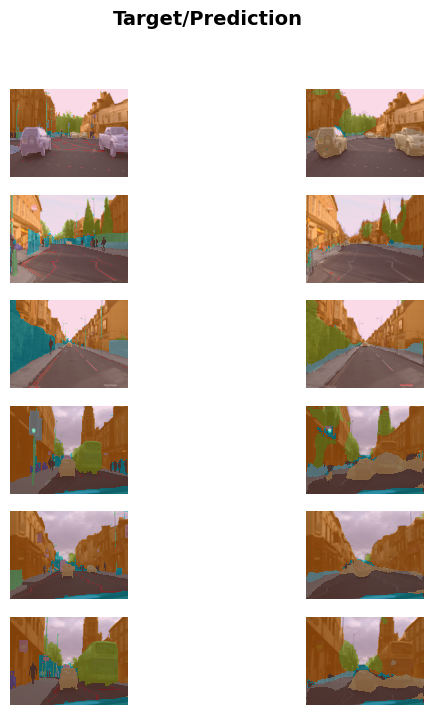

In [5]:
learn.show_results(max_n = 6, figsize = (7,8)) 
# max_n is the max no. of images to diaplay(in result)
# figsize is the image size(7x8inches)

In [9]:
# Defining the Pixel Accuracy Function. This calculates accuracy for Every pixel in the image.
def acc_seg(input, target):
    target = target.squeeze(1)
    return (input.argmax(dim=1)==target).float().mean()

'''
# input: 
    When a segmentation model looks at a pixel, it doesn't just say 'Car'. It outputs a list of probabilies of every possible object.
    - Input shape: [8,32,128,128]
    - (8 images, 32 possible classes, 128 height, 128 width)
    - For one specific pixel, the AI might say: [Sky: 0.1, Road: 0.8, Car: 0.1]
# input.argmax(dim=1) (The winner takes all)
    The AI cant color a pixel 2 or 3 colors so argmax tells the computer to find the index of highest number in the above list.
    - Here Road(0.8) is then turned into 1.
# target.squeeze(1) (Fitting the puzzle pieces)
    Computers are vey picky about "Shapes".
    - The Input(after argmax) is a flat 2D grid of numbers.
    - The Target(the human-painted mask) often comes in as a 3D "sandwich" with a thickness of 1.
    - squeeze(1) flattens that "sandwich" so it's a flat 2D grid. Now the two grids can be laid perfectly on top of each other.
# ==target (The Transparency Test)
    Let the AI colored grid is on a piece of paper and Human painted "Answer Key" on another. On overlaying AI colored on human colored
    - If the pixel matches(like 1(Road) with 2(Road)) result is True(1) else False(0).
# .float().mean()  (The Final Score)
    This takes all those 1s(Correct) and 0s(Wrong) and finds the average.
    e.g. out of 10 pixels, 8 are 'true' the math is 8/10 = 0.8
'''  

# AI uses loss function to learn and update its brain, but we as Humans see metrics.
# Assigning metrics to the learner
# We use acc_seg for 'Global' accuracy and foregroung_acc for 'Object focus'. foreground is a fastai function ans avoids background/void
learn.metrics = [acc_seg, foreground_acc]

# Running validation pass. validate() commands AI to run through Validation Set once.
results = learn.validate()

# results is a list.
print(f"Validation Loss: {results[0]:.4f}")    # results[0] is always the avg. Validation Loss(of all batches)
print(f"Global Accuracy: {results[1]*100:.2f}% (Every Pixel Counted)") 
print(f"Pixel Accuracy: {results[2]*100:.2f}% (Ignoring background/void)") # results[1] is the Metric we choose(acc_seg)(here)

# Re-defining here to ensure no NameErrors
codes = np.loadtxt(path/'codes.txt',dtype=str)

print(f"\nObject List: {codes}") # This prints the list of all object names in order
print(f"Class 4 is: {codes[4]}") # To find a specific mapping (e.g., what is Class 4?)

# acc_seg is the pixel accuracy for segmentation. It looks at every single pixel and ask : "Dis the AI pick the right color for this pixel?"
# But why not accuracy? To avoid "void" or "background" pixels.

Validation Loss: 0.8064
Global Accuracy: 78.27% (Every Pixel Counted)
Pixel Accuracy: 78.27% (Ignoring background/void)

Object List: ['Animal' 'Archway' 'Bicyclist' 'Bridge' 'Building' 'Car'
 'CartLuggagePram' 'Child' 'Column_Pole' 'Fence' 'LaneMkgsDriv'
 'LaneMkgsNonDriv' 'Misc_Text' 'MotorcycleScooter' 'OtherMoving'
 'ParkingBlock' 'Pedestrian' 'Road' 'RoadShoulder' 'Sidewalk' 'SignSymbol'
 'Sky' 'SUVPickupTruck' 'TrafficCone' 'TrafficLight' 'Train' 'Tree'
 'Truck_Bus' 'Tunnel' 'VegetationMisc' 'Void' 'Wall']
Class 4 is: Building


### Initially, the model had a high validation loss of 2.30, so I implemented a U-Net with a ResNet-34 backbone and fine-tuned it for 8 epochs; while this successfully pushed the loss down to 0.79, the slight rise in the final epoch suggests it reached its limit on this tiny dataset, so to improve it further, I would need to implement Data Augmentation and Progreessive Resizing to break past that 80% accuracy barrier.
